# 🚦 Traffic Accident Severity Prediction 


FULL PREPROCESSING PIPELINE

Dataset : traffic_accident_dataset.csv  (~8 400 rows, 26 columns)
Target  : accident_severity  (Minor | Moderate | Severe)
Goal    : Clean, encode, scale — ready for Logistic Regression & SVM models


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading & Preprocessing

╔══════════════════════════════════════════════════════════════════════════╗
║  CELL 1 — DATA INSPECTION                                                ║
╚══════════════════════════════════════════════════════════════════════════╝
WHY: Before touching a single value we need a full picture of what we have.
     Knowing dtypes, null counts, and cardinality prevents silent mistakes
     in every later step.


In [4]:

# ── 1.1  Load ──────────────────────────────────────────────────────────────
df = pd.read_csv("traffic_accident_dataset.csv")

print(f"\n▶ Raw shape  : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")



▶ Raw shape  : (8400, 26)  (8400 rows × 26 columns)


── 1.2  Data types ────────────────────────────────────────────────────────
WHY: We must know which columns are numeric vs categorical so we apply the
     right imputation and encoding strategies later.


In [5]:
print("\n▶ Column dtypes:")
print(df.dtypes.to_string())


▶ Column dtypes:
accident_id               object
date                      object
time                      object
day_of_week               object
hour                       int64
state                     object
road_type                 object
junction_type             object
weather_condition         object
road_condition            object
light_condition           object
speed_kmh                float64
speed_limit_kmh            int64
visibility_m             float64
num_vehicles               int64
driver_age               float64
driver_experience_yrs    float64
vehicle_type              object
alcohol_involved         float64
seatbelt_worn            float64
num_casualties             int64
redundant_record_id        int64
system_flag               object
random_noise_code          int64
useless_ratio            float64
accident_severity         object


── 1.3  Missing-value audit ───────────────────────────────────────────────
WHY: Quantifying nulls per column tells us the severity of data loss.
     If a column is >50 % null we'd consider dropping it entirely.


In [6]:
# ── 1.3  Missing-value audit ───────────────────────────────────────────────
# WHY: Quantifying nulls per column tells us the severity of data loss.
#      If a column is >50 % null we'd consider dropping it entirely.
null_counts  = df.isnull().sum()
null_percent = (null_counts / len(df) * 100).round(2)
null_report  = pd.DataFrame({"Missing #": null_counts,
                              "Missing %": null_percent})
null_report  = null_report[null_report["Missing #"] > 0].sort_values("Missing %", ascending=False)

print(f"\n▶ Columns with missing values ({len(null_report)} found):")
print(null_report.to_string())


▶ Columns with missing values (11 found):
                       Missing #  Missing %
junction_type               2448      29.14
weather_condition            858      10.21
visibility_m                 858      10.21
vehicle_type                 858      10.21
driver_age                   856      10.19
road_condition               852      10.14
alcohol_involved             846      10.07
seatbelt_worn                846      10.07
speed_kmh                    837       9.96
light_condition              797       9.49
driver_experience_yrs        796       9.48


── 1.4  Descriptive statistics ────────────────────────────────────────────
WHY: Mean / std / min / max reveal whether numerical features have
     plausible ranges and hint at likely outliers (e.g., speed > 200 km/h).


In [8]:
print("\n▶ Descriptive stats (numerical columns):")
print(df.describe(include=[np.number]).round(2).to_string())


▶ Descriptive stats (numerical columns):
          hour  speed_kmh  speed_limit_kmh  visibility_m  num_vehicles  driver_age  driver_experience_yrs  alcohol_involved  seatbelt_worn  num_casualties  redundant_record_id  random_noise_code  useless_ratio
count  8400.00    7563.00          8400.00       7542.00       8400.00     7544.00                7604.00           7554.00        7554.00         8400.00              8400.00            8400.00        8400.00
mean     12.48      73.31            66.56        518.89          2.30       37.71                  10.27              0.18           0.70            1.67              3999.23          548509.16           0.51
std       6.03      27.31            25.84        238.23          1.51       11.74                   6.04              0.38           0.46            1.86              2305.59          262217.69           0.29
min       0.00      10.00            30.00         50.00          1.00       16.00                   0.00             

── 1.5  Target-class distribution ────────────────────────────────────────
WHY: Imbalanced classes require resampling or weighted models.
     We expect roughly equal thirds (Minor / Moderate / Severe).


In [9]:
print("\n▶ Target class distribution:")
print(df["accident_severity"].value_counts())


▶ Target class distribution:
accident_severity
Severe      2806
Minor       2805
Moderate    2789
Name: count, dtype: int64


── 1.6  Categorical cardinality ──────────────────────────────────────────
WHY: High-cardinality columns (many unique values) are expensive to
     one-hot-encode and may need special handling.


In [10]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("\n▶ Unique values per categorical column:")
for c in cat_cols:
    print(f"   {c:<28} → {df[c].nunique()} unique values")

print(f"\n✔  Inspection complete.\n")


▶ Unique values per categorical column:
   accident_id                  → 8000 unique values
   date                         → 1448 unique values
   time                         → 24 unique values
   day_of_week                  → 7 unique values
   state                        → 20 unique values
   road_type                    → 5 unique values
   junction_type                → 4 unique values
   weather_condition            → 24 unique values
   road_condition               → 5 unique values
   light_condition              → 5 unique values
   vehicle_type                 → 6 unique values
   system_flag                  → 1 unique values
   accident_severity            → 3 unique values

✔  Inspection complete.



╔══════════════════════════════════════════════════════════════════════════╗
║  CELL 2 — DATA CLEANING                                                  ║
╚══════════════════════════════════════════════════════════════════════════╝
WHY: Real-world data is dirty. Nulls, duplicates, and inconsistent labels
     all introduce noise that degrades model performance.


── 2.1  Remove duplicate rows ────────────────────────────────────────────
WHY: Duplicates bias training — a model will overfit on repeated rows and
     validation metrics will be over-optimistic if duplicates leak across
     the train/test split.


In [11]:
n_before = len(df)
df = df.drop_duplicates()
n_after  = len(df)
print(f"\n▶ Duplicates removed : {n_before - n_after}  (rows: {n_before} → {n_after})")


▶ Duplicates removed : 400  (rows: 8400 → 8000)


── 2.2  Fix categorical inconsistencies ──────────────────────────────────
WHY: "Clear", "CLEAR", "clear", "Sunny", "Fair" all mean the same thing.
     If left as-is, a label encoder treats them as 5 different categories,
     fragmenting signal and inflating dimensionality.


### weather_condition


In [12]:
weather_map = {
    # variants → canonical form
    "clear"       : "Clear",  "CLEAR"       : "Clear",  "sunny"    : "Clear",
    "Sunny"       : "Clear",  "Fair"        : "Clear",  "fair"     : "Clear",
    "rainy"       : "Rainy",  "Rain"        : "Rainy",  "rain"     : "Rainy",
    "Raining"     : "Rainy",  "Wet Weather" : "Rainy",  "raining"  : "Rainy",
    "foggy"       : "Foggy",  "Fog"         : "Foggy",  "fog"      : "Foggy",
    "Misty"       : "Foggy",  "misty"       : "Foggy",
    "snowy"       : "Snowy",  "Snow"        : "Snowy",  "snow"     : "Snowy",
    "Snow Fall"   : "Snowy",  "snow fall"   : "Snowy",
    "windy"       : "Windy",  "High Wind"   : "Windy",  "high wind": "Windy",
    "Storm"       : "Stormy", "storm"       : "Stormy", "stormy"   : "Stormy",
    "Thunderstorm": "Stormy",
}
# Apply: unknown values fall back to title-case of themselves
df["weather_condition"] = (
    df["weather_condition"].map(lambda x: weather_map.get(x, x) if pd.notna(x) else x)
)

### state — collapse free-text variants to standard 2-letter codes

In [13]:
state_map = {
    "New York"  : "NY",  "N.Y."  : "NY",  "ny"  : "NY",
    "California": "CA",  "CA."   : "CA",  "ca"  : "CA",
    "Texas"     : "TX",  "Tx"    : "TX",  "tx"  : "TX",
    "Florida"   : "FL",  "fl"    : "FL",
    "Illinois"  : "IL",  "Ill."  : "IL",  "il"  : "IL",
    "Ohio"      : "OH",  "oh"    : "OH",
    "Washington": "WA",  "wa"    : "WA",
}
df["state"] = df["state"].map(lambda x: state_map.get(x, x) if pd.notna(x) else x)

print("\n▶ After standardisation:")
print(f"   weather_condition unique values : {sorted(df['weather_condition'].dropna().unique())}")
print(f"   state             unique values : {sorted(df['state'].dropna().unique())}")




▶ After standardisation:
   weather_condition unique values : ['Clear', 'Foggy', 'Rainy', 'Snowy', 'Stormy', 'Windy']
   state             unique values : ['CA', 'FL', 'IL', 'NY', 'OH', 'TX', 'WA']


── 2.3  Impute missing values ────────────────────────────────────────────
WHY: Most ML algorithms (Logistic Regression, SVM) cannot accept NaN.
     We use MEDIAN for numerics (robust to outliers vs mean) and
     MODE for categoricals (most frequent class is the safest guess).


In [14]:

num_cols_with_null = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
].tolist()
cat_cols_with_null = [c for c in df.select_dtypes(include="object").columns
                      if df[c].isnull().any() and c != "accident_severity"]

print(f"\n▶ Imputing {len(num_cols_with_null)} numerical column(s) with median:")
for col in num_cols_with_null:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"   {col:<30} → filled with median = {median_val:.2f}")

print(f"\n▶ Imputing {len(cat_cols_with_null)} categorical column(s) with mode:")
for col in cat_cols_with_null:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"   {col:<30} → filled with mode  = '{mode_val}'")

# ── 2.4  Verify cleanliness ───────────────────────────────────────────────
remaining_nulls = df.isnull().sum().sum()
print(f"\n▶ Total nulls remaining : {remaining_nulls}  ({'✔ None!' if remaining_nulls == 0 else '⚠ Check above'})")
print(f"▶ Rows after cleaning   : {len(df)}")
print(f"\n✔  Cleaning complete.\n")



▶ Imputing 6 numerical column(s) with median:
   speed_kmh                      → filled with median = 70.70
   visibility_m                   → filled with median = 501.20
   driver_age                     → filled with median = 37.00
   driver_experience_yrs          → filled with median = 10.10
   alcohol_involved               → filled with median = 0.00
   seatbelt_worn                  → filled with median = 1.00

▶ Imputing 5 categorical column(s) with mode:
   junction_type                  → filled with mode  = 'Crossroads'
   weather_condition              → filled with mode  = 'Clear'
   road_condition                 → filled with mode  = 'Dry'
   light_condition                → filled with mode  = 'Daylight'
   vehicle_type                   → filled with mode  = 'SUV'

▶ Total nulls remaining : 0  (✔ None!)
▶ Rows after cleaning   : 8000

✔  Cleaning complete.



╔══════════════════════════════════════════════════════════════════════════╗
║  CELL 3 — OUTLIER MANAGEMENT                                             ║
╚══════════════════════════════════════════════════════════════════════════╝
WHY: Extreme values skew linear models and SVMs by dominating the loss.
     We use the IQR method to flag outliers, then CLIP (Winsorise) them
     instead of dropping rows — preserving sample size.


In [15]:
print("CELL 3 — OUTLIER MANAGEMENT")
# Columns where outlier control makes physical sense
outlier_cols = ["speed_kmh", "visibility_m", "driver_age",
                "driver_experience_yrs", "num_casualties", "num_vehicles"]

print("\n▶ IQR-based outlier detection & clipping:")
outlier_summary = []

for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Standard Tukey fence: 1.5 × IQR
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()

    # Clip to fence — keeps the row, reins in the extreme value
    df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)

    outlier_summary.append({
        "Column"     : col,
        "Q1"         : round(Q1, 2),
        "Q3"         : round(Q3, 2),
        "IQR"        : round(IQR, 2),
        "Lower Fence": round(lower_fence, 2),
        "Upper Fence": round(upper_fence, 2),
        "# Clipped"  : n_outliers,
    })

outlier_df = pd.DataFrame(outlier_summary).set_index("Column")
print(outlier_df.to_string())



CELL 3 — OUTLIER MANAGEMENT

▶ IQR-based outlier detection & clipping:
                           Q1      Q3     IQR  Lower Fence  Upper Fence  # Clipped
Column                                                                            
speed_kmh               53.60   94.03   40.43        -7.05       154.68          0
visibility_m           328.05  729.72  401.68      -274.46      1332.24          0
driver_age              31.00   45.00   14.00        10.00        66.00         57
driver_experience_yrs    6.30   13.90    7.60        -5.10        25.30         61
num_casualties           0.00    3.00    3.00        -4.50         7.50         64
num_vehicles             1.00    3.00    2.00        -2.00         6.00        139


── 3.1  Visual check — before/after already captured in clip ─────────────
WHY: Boxplots confirm our fence logic was applied correctly.

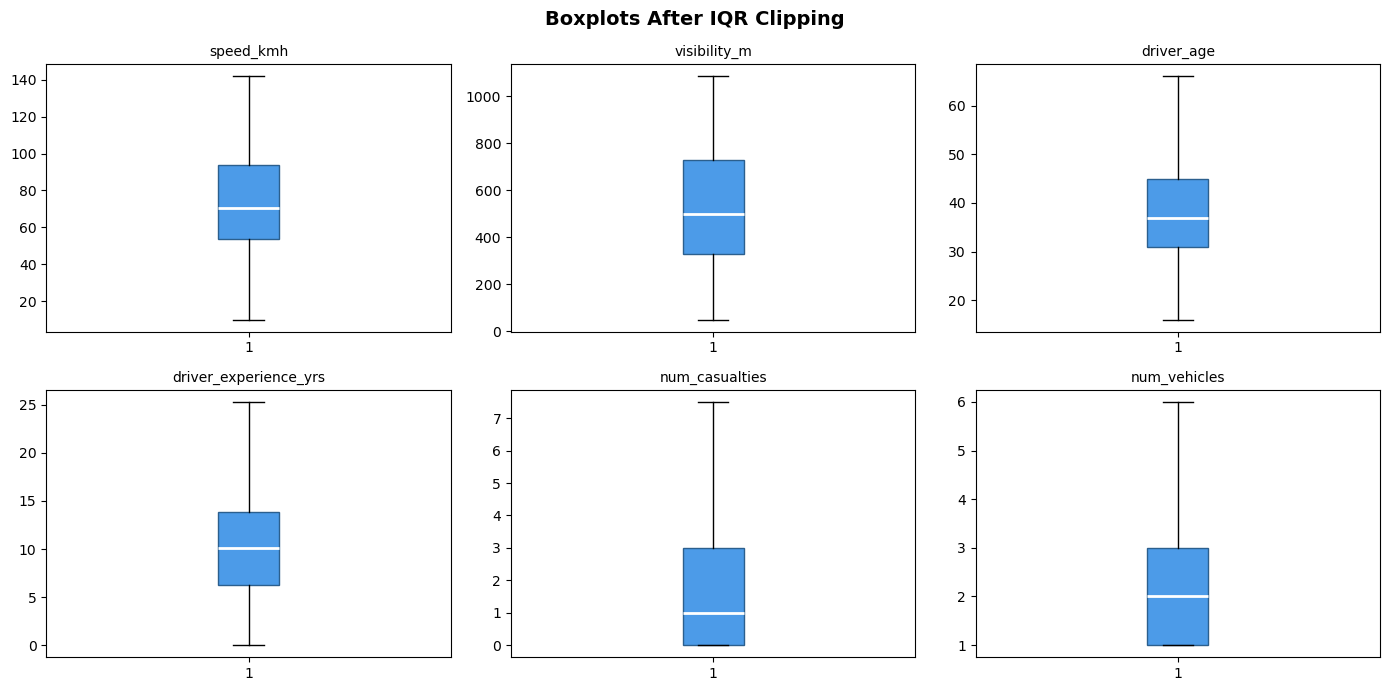


▶ Boxplot saved → boxplots_after_clipping.png

✔  Outlier management complete.



In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Boxplots After IQR Clipping", fontsize=14, fontweight="bold")
for ax, col in zip(axes.flat, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C9BE8", color="#2b5f8e"),
               medianprops=dict(color="white", linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()
# plt.savefig("boxplots_after_clipping.png", dpi=120, bbox_inches="tight")
# plt.close()
print("\n▶ Boxplot saved → boxplots_after_clipping.png")
print(f"\n✔  Outlier management complete.\n")


╔══════════════════════════════════════════════════════════════════════════╗
║  CELL 4 — FEATURE ENGINEERING                                            ║
╚══════════════════════════════════════════════════════════════════════════╝
WHY: Raw columns need transformation before modelling:
     1. Drop noise/ID columns — they carry zero predictive signal and
        inflate dimensionality.
     2. Derive new features that expose domain knowledge.
     3. Encode categoricals — algorithms need numbers.


── 4.1  Drop noise / irrelevant columns ─────────────────────────────────
WHY: Keeping redundant columns wastes compute and can confuse tree-based
     models (random IDs can look like "perfect" predictors on training data).


In [17]:
DROP_COLS = [
    "accident_id",        # unique string ID — no signal
    "redundant_record_id",# plain row counter — identical info as index
    "system_flag",        # constant "PROCESSED" — zero variance
    "random_noise_code",  # random integer — pure noise
    "useless_ratio",      # random float — no signal
    "date",               # already decomposed into hour / day_of_week below
    "time",               # ditto
]

df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f"\n▶ Dropped {len(DROP_COLS)} noise/ID columns: {DROP_COLS}")


▶ Dropped 7 noise/ID columns: ['accident_id', 'redundant_record_id', 'system_flag', 'random_noise_code', 'useless_ratio', 'date', 'time']


── 4.2  Feature: speed excess over limit ────────────────────────────────
WHY: The raw speed value is less informative than *how much it exceeds
     the legal limit* — a common factor in accident severity scoring.

In [18]:
df["speed_excess_kmh"] = (df["speed_kmh"] - df["speed_limit_kmh"]).clip(lower=0)
print("\n▶ New feature 'speed_excess_kmh' = max(speed - speed_limit, 0)")


▶ New feature 'speed_excess_kmh' = max(speed - speed_limit, 0)


── 4.3  Feature: is_night ────────────────────────────────────────────────
WHY: Night driving is a known risk factor. Converting hour to a binary
     flag makes this non-linear relationship visible to linear models.


In [19]:
df["is_night"] = df["hour"].apply(lambda h: 1 if (h >= 21 or h <= 5) else 0)
print("▶ New feature 'is_night' = 1 if hour ∈ {21..23, 0..5}")

▶ New feature 'is_night' = 1 if hour ∈ {21..23, 0..5}


── 4.4  Encode target label ──────────────────────────────────────────────
WHY: Scikit-Learn classifiers expect integer class labels.
     We keep the mapping explicit so outputs are interpretable.


In [20]:
target_mapping = {"Minor": 0, "Moderate": 1, "Severe": 2}
df["accident_severity"] = df["accident_severity"].map(target_mapping)
print(f"\n▶ Target encoding: {target_mapping}")
print(f"   Class counts:\n{df['accident_severity'].value_counts().sort_index().to_string()}")


▶ Target encoding: {'Minor': 0, 'Moderate': 1, 'Severe': 2}
   Class counts:
accident_severity
0    2667
1    2666
2    2667


── 4.5  Encode categorical features ─────────────────────────────────────
WHY: Logistic Regression and SVM need numerical inputs.
     For nominal categoricals with many values we use LabelEncoder (compact).
     For a production system with unseen categories, OrdinalEncoder with
     handle_unknown='use_encoded_value' would be safer.

In [21]:
CAT_FEATURES = [
    "day_of_week", "state", "road_type", "junction_type",
    "weather_condition", "road_condition", "light_condition", "vehicle_type",
]

le = LabelEncoder()
print(f"\n▶ Label-encoding {len(CAT_FEATURES)} categorical columns:")
for col in CAT_FEATURES:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"   {col:<28} → int  (classes: {df[col].nunique()})")

print(f"\n▶ Final shape after feature engineering: {df.shape}")
print(f"\n✔  Feature engineering complete.\n")


▶ Label-encoding 8 categorical columns:
   day_of_week                  → int  (classes: 7)
   state                        → int  (classes: 7)
   road_type                    → int  (classes: 5)
   junction_type                → int  (classes: 4)
   weather_condition            → int  (classes: 6)
   road_condition               → int  (classes: 5)
   light_condition              → int  (classes: 5)
   vehicle_type                 → int  (classes: 6)

▶ Final shape after feature engineering: (8000, 21)

✔  Feature engineering complete.



╔══════════════════════════════════════════════════════════════════════════╗
║  CELL 5 — FEATURE SCALING                                                ║
╚══════════════════════════════════════════════════════════════════════════╝
WHY: SVM (all kernels) and Logistic Regression are distance/gradient-based.
     Without scaling, a column with range [0, 200] (speed) dominates over
     one with range [0, 1] (alcohol_involved), biasing the model heavily.
     StandardScaler transforms each feature to mean=0, std=1.



─ 5.1  Train / test split FIRST ────────────────────────────────────────
WHY: Fit the scaler ONLY on training data, then transform test data.
     Fitting on the full dataset leaks test-set statistics into training
     ("data leakage"), producing over-optimistic evaluation results.
     

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["accident_severity"])
y = df["accident_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n▶ Train set : {X_train.shape[0]} rows  |  Test set : {X_test.shape[0]} rows")
print(f"   Stratified split — class distribution preserved.")


▶ Train set : 6400 rows  |  Test set : 1600 rows
   Stratified split — class distribution preserved.



── 5.2  Identify columns to scale ───────────────────────────────────────
WHY: Binary (0/1) columns and label-encoded categoricals don't need scaling
     (their range is already narrow and uniform). We scale only the
     continuous numerical columns.


In [23]:
SCALE_COLS = [
    "speed_kmh", "speed_limit_kmh", "visibility_m",
    "driver_age", "driver_experience_yrs", "num_vehicles",
    "num_casualties", "hour", "speed_excess_kmh",
]
# Keep only those that survived into X
SCALE_COLS = [c for c in SCALE_COLS if c in X_train.columns]

print(f"\n▶ Columns being scaled ({len(SCALE_COLS)}):")
for c in SCALE_COLS:
    print(f"   {c}")

# ── 5.3  Fit on train, transform both sets ────────────────────────────────
scaler = StandardScaler()
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])   # ← use TRAIN stats

print("\n▶ Post-scaling stats for X_train (should be ≈ mean=0, std=1):")
scaled_stats = X_train[SCALE_COLS].describe().loc[["mean", "std"]].round(3)
print(scaled_stats.to_string())


▶ Columns being scaled (9):
   speed_kmh
   speed_limit_kmh
   visibility_m
   driver_age
   driver_experience_yrs
   num_vehicles
   num_casualties
   hour
   speed_excess_kmh

▶ Post-scaling stats for X_train (should be ≈ mean=0, std=1):
      speed_kmh  speed_limit_kmh  visibility_m  driver_age  driver_experience_yrs  num_vehicles  num_casualties  hour  speed_excess_kmh
mean        0.0             -0.0          -0.0        -0.0                    0.0           0.0             0.0  -0.0               0.0
std         1.0              1.0           1.0         1.0                    1.0           1.0             1.0   1.0               1.0



── 5.4  Correlation heatmap — final feature set ─────────────────────────
WHY: A quick sanity check.  High inter-feature correlations (>0.9) suggest
     redundant features that could be dropped to reduce multicollinearity.


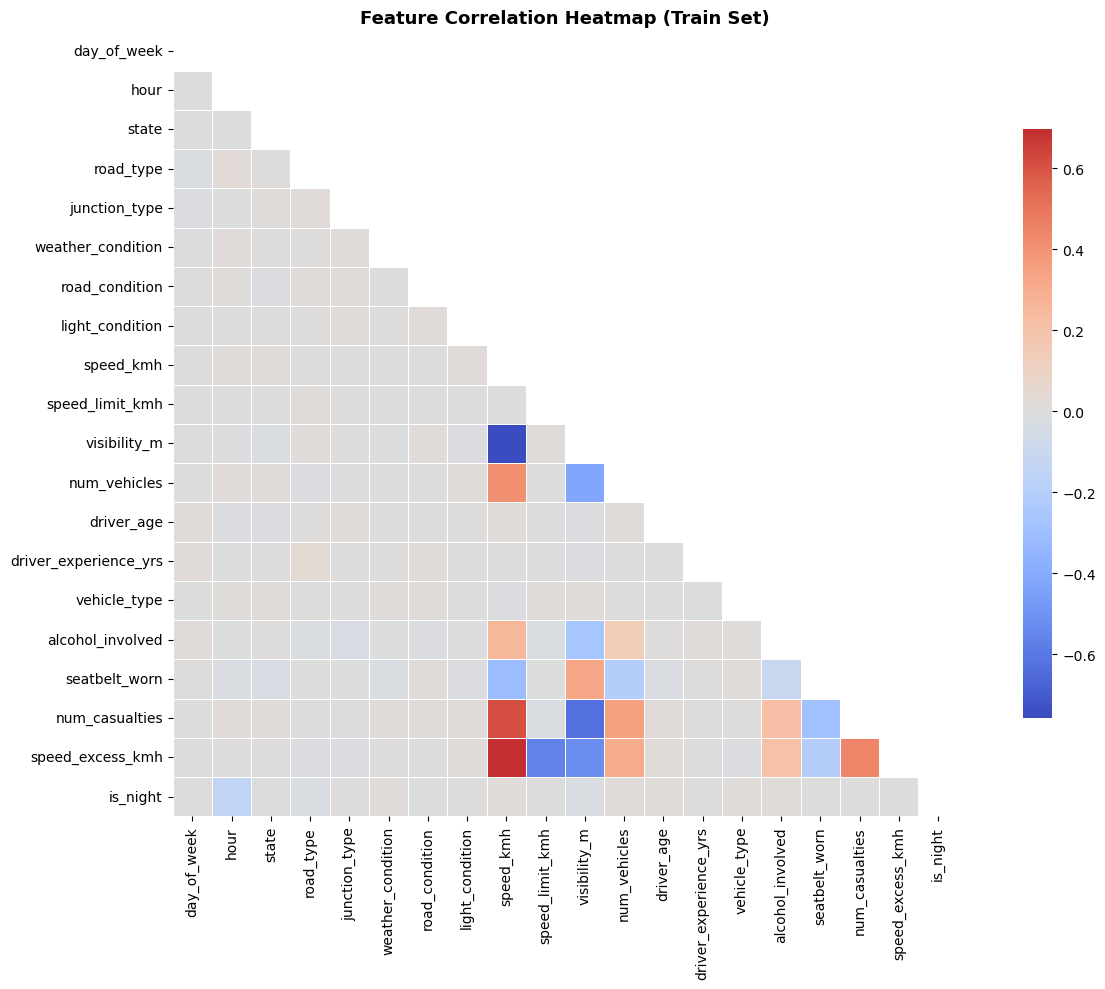


▶ Heatmap saved → feature_correlation_heatmap.png

▶ Saved → train_preprocessed.csv  &  test_preprocessed.csv

✔  Scaling complete.



In [24]:
plt.figure(figsize=(14, 10))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.4, square=True,
            cbar_kws={"shrink": 0.75})
plt.title("Feature Correlation Heatmap (Train Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# plt.savefig("feature_correlation_heatmap.png", dpi=120, bbox_inches="tight")
# plt.close()
print("\n▶ Heatmap saved → feature_correlation_heatmap.png")

# ── 5.5  Save preprocessed splits ────────────────────────────────────────
X_train_out = X_train.copy(); X_train_out["accident_severity"] = y_train.values
X_test_out  = X_test.copy();  X_test_out["accident_severity"]  = y_test.values

X_train_out.to_csv("train_preprocessed.csv", index=False)
X_test_out.to_csv("test_preprocessed.csv",   index=False)
print("\n▶ Saved → train_preprocessed.csv  &  test_preprocessed.csv")

print(f"\n✔  Scaling complete.\n")

╔══════════════════════════════════════════════════════════════════════════╗
║  PIPELINE SUMMARY                                                        ║
╚══════════════════════════════════════════════════════════════════════════╝

In [25]:
print("PIPELINE SUMMARY")
summary = {
    "Final train rows"      : len(X_train),
    "Final test rows"       : len(X_test),
    "Total features (X)"    : X_train.shape[1],
    "Target classes"        : sorted(y.unique().tolist()),
    "Scaled columns"        : len(SCALE_COLS),
    "Encoded cat. columns"  : len(CAT_FEATURES),
    "New engineered features": 2,   # speed_excess_kmh, is_night
}
for k, v in summary.items():
    print(f"   {k:<35} : {v}")

print(f"\n{'─'*70}")
print("  Ready for : Feature Selection")
print(f"{'─'*70}\n")


PIPELINE SUMMARY
   Final train rows                    : 6400
   Final test rows                     : 1600
   Total features (X)                  : 20
   Target classes                      : [0, 1, 2]
   Scaled columns                      : 9
   Encoded cat. columns                : 8
   New engineered features             : 2

──────────────────────────────────────────────────────────────────────
  Ready for : Feature Selection
──────────────────────────────────────────────────────────────────────



# 2.  Feature Selection via GridSearchCV

### 💡 Why GridSearchCV for Feature Selection?
> Instead of manually picking a threshold, **GridSearchCV treats `k` (number of features)**  
> **as a hyperparameter and finds the value that maximises recall via cross-validation.**  
> This is more principled than heuristic thresholds — the model itself tells us  
> how many features it needs.

---
## 📦 Cell 6 — Setup & Load Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline         import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.model_selection  import GridSearchCV, StratifiedKFold
from sklearn.metrics          import (
    confusion_matrix, recall_score, classification_report
)

pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

PALETTE     = ['#4C9BE8', '#F4A261', '#E63946']
CLASS_NAMES = ['Minor (0)', 'Moderate (1)', 'Severe (2)']
TARGET      = 'accident_severity'
print('✔  Libraries loaded.')

✔  Libraries loaded.


In [27]:
train = pd.read_csv('train_preprocessed.csv')
test  = pd.read_csv('test_preprocessed.csv')

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

print(f'Train : {X_train.shape}   Test : {X_test.shape}')
print(f'\nAll available features ({len(X_train.columns)}):')
print(list(X_train.columns))

Train : (6400, 20)   Test : (1600, 20)

All available features (20):
['day_of_week', 'hour', 'state', 'road_type', 'junction_type', 'weather_condition', 'road_condition', 'light_condition', 'speed_kmh', 'speed_limit_kmh', 'visibility_m', 'num_vehicles', 'driver_age', 'driver_experience_yrs', 'vehicle_type', 'alcohol_involved', 'seatbelt_worn', 'num_casualties', 'speed_excess_kmh', 'is_night']


###### ---
## 🔍 Cell 6.1 — Feature Selection via GridSearchCV
> **Core Idea:**  
> We wrap `SelectKBest(f_classif)` + a fast `LogisticRegression` inside a `Pipeline`.  
> `GridSearchCV` then searches over every value of `k` (1 … total features) using  
> **5-fold Stratified Cross-Validation**, scoring each `k` by **macro recall**.  
> The `k` with the highest mean CV recall becomes our feature count.
>
> ```
> Pipeline
>   └── Step 1 : SelectKBest(f_classif, k=?)   ← k is the search parameter
>   └── Step 2 : LogisticRegression             ← fast scorer inside CV
>
> GridSearchCV searches k ∈ {1, 2, 3, …, n_features}
> Scoring = 'recall_macro'   (most important metric for severity prediction)
> CV      = StratifiedKFold(5)  (preserves class ratios per fold)
> ```

### 6.2 Build Pipeline & Run GridSearchCV

In [28]:
# ── Pipeline: SelectKBest → LogisticRegression ───────────────────────────
# WHY LogisticRegression as the scorer inside GridSearchCV?
#   It's fast (critical when CV runs k × 5 folds) and gives a clean recall
#   signal. The best-k found here is then applied to ALL four final models.
pipe = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),  # ANOVA F-test ranks features
    ('clf',      LogisticRegression(max_iter=500, random_state=42))
])

# ── Parameter grid ────────────────────────────────────────────────────────
# WHY search all k values?
#   We have only ~20 features, so searching all k costs 20×5 = 100 fits —
#   negligible. For wider datasets, restrict to a range instead.
n_features = X_train.shape[1]
param_grid = {
    'selector__k': list(range(1, n_features + 1))  # k = 1 … 20
}

# ── Cross-validation strategy ─────────────────────────────────────────────
# WHY StratifiedKFold?
#   Each fold preserves the Minor/Moderate/Severe ratio, preventing a fold
#   from accidentally containing very few 'Severe' examples.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── GridSearchCV ─────────────────────────────────────────────────────────
# WHY scoring='recall_macro'?
#   Macro recall weights every class equally — critical because missing a
#   'Severe' accident is as costly as missing a 'Minor' one statistically.
grid_search = GridSearchCV(
    estimator  = pipe,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'recall_macro',
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True
)

print(f'Searching k ∈ {{1 … {n_features}}} across {cv.n_splits}-fold CV ...')
grid_search.fit(X_train, y_train)
print(f'\n✔  Grid search complete.')
print(f'   Best k              : {grid_search.best_params_["selector__k"]}')
print(f'   Best CV macro recall: {grid_search.best_score_:.4f}')

Searching k ∈ {1 … 20} across 5-fold CV ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✔  Grid search complete.
   Best k              : 8
   Best CV macro recall: 0.9494


### 6.3 CV Results — Recall vs k

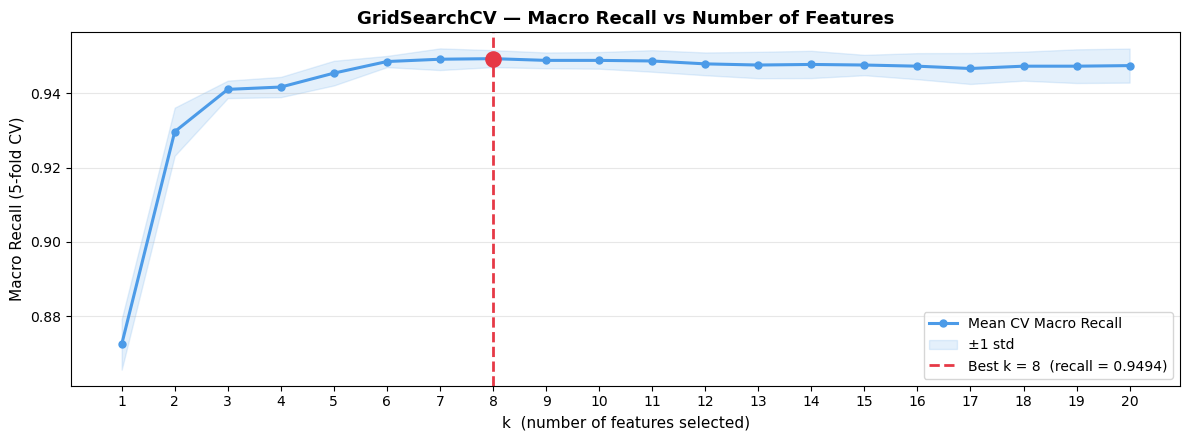


Full CV results table (sorted by mean recall):


,param_selector__k,mean_test_score,std_test_score,mean_train_score
7,8,0.9494,0.0023,0.9507
6,7,0.9492,0.0029,0.9504
8,9,0.9489,0.0021,0.9508
9,10,0.9489,0.0022,0.9506
10,11,0.9487,0.0029,0.9507
5,6,0.9486,0.0015,0.9505
11,12,0.9480,0.0031,0.9509
13,14,0.9478,0.0037,0.9506
14,15,0.9477,0.0027,0.9507
12,13,0.9477,0.0036,0.9508


In [29]:
cv_results = pd.DataFrame(grid_search.cv_results_)
k_values   = cv_results['param_selector__k'].astype(int)
mean_recall = cv_results['mean_test_score']
std_recall  = cv_results['std_test_score']
best_k      = grid_search.best_params_['selector__k']

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(k_values, mean_recall, color='#4C9BE8', linewidth=2.2,
        marker='o', markersize=5, label='Mean CV Macro Recall')
ax.fill_between(k_values,
                mean_recall - std_recall,
                mean_recall + std_recall,
                alpha=0.15, color='#4C9BE8', label='±1 std')
ax.axvline(best_k, color='#E63946', linestyle='--', linewidth=2,
           label=f'Best k = {best_k}  (recall = {grid_search.best_score_:.4f})')
ax.scatter([best_k], [grid_search.best_score_],
           color='#E63946', s=120, zorder=5)

ax.set_xlabel('k  (number of features selected)', fontsize=11)
ax.set_ylabel('Macro Recall (5-fold CV)', fontsize=11)
ax.set_title('GridSearchCV — Macro Recall vs Number of Features',
             fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nFull CV results table (sorted by mean recall):')
cv_results[['param_selector__k','mean_test_score','std_test_score',
            'mean_train_score']].sort_values('mean_test_score', ascending=False).head(10)

### 6.4 Extract Selected Features

In [30]:
# Retrieve the fitted SelectKBest from the best pipeline
best_selector  = grid_search.best_estimator_.named_steps['selector']
feature_mask   = best_selector.get_support()          # boolean mask
final_features = X_train.columns[feature_mask].tolist()
f_scores_all   = best_selector.scores_

print(f'Best k = {best_k}  →  {len(final_features)} features selected:')
for i, f in enumerate(final_features, 1):
    print(f'  {i:2d}. {f}')

Best k = 8  →  8 features selected:
   1. speed_kmh
   2. visibility_m
   3. num_vehicles
   4. alcohol_involved
   5. seatbelt_worn
   6. num_casualties
   7. speed_excess_kmh
   8. is_night


### 6.5 Feature Importance Bar Chart (ANOVA F-Scores)

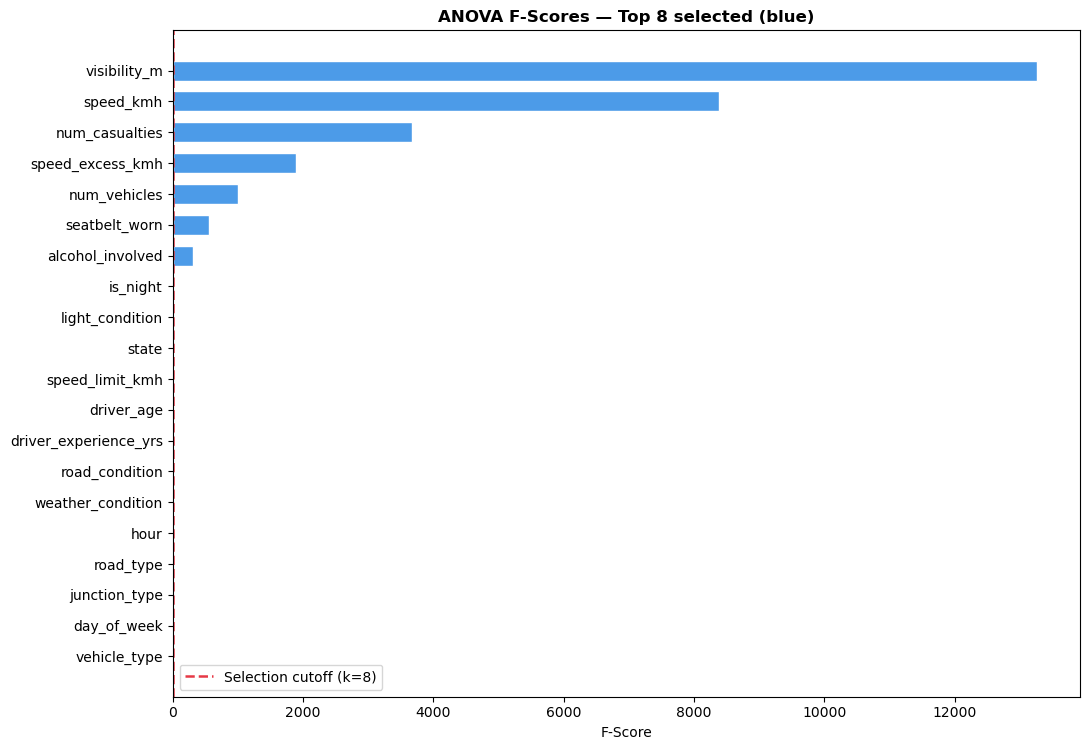


X_train_sel : (6400, 8)
X_test_sel  : (1600, 8)


In [31]:
f_score_series = pd.Series(f_scores_all, index=X_train.columns).sort_values(ascending=False)
cutoff_score   = f_score_series.iloc[best_k - 1]   # threshold at k-th ranked feature

fig, ax = plt.subplots(figsize=(11, max(4, len(f_score_series)*0.38)))
bar_colors = ['#4C9BE8' if f in final_features else '#cccccc'
              for f in f_score_series.index]
ax.barh(f_score_series.index[::-1], f_score_series.values[::-1],
        color=bar_colors[::-1], edgecolor='white', height=0.65)
ax.axvline(cutoff_score, color='#E63946', linestyle='--', linewidth=1.8,
           label=f'Selection cutoff (k={best_k})')
ax.set_title(f'ANOVA F-Scores — Top {best_k} selected (blue)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('F-Score')
ax.legend()
plt.tight_layout(); plt.show()

# Apply selection to train & test
X_train_sel = X_train[final_features].copy()
X_test_sel  = X_test[final_features].copy()
print(f'\nX_train_sel : {X_train_sel.shape}')
print(f'X_test_sel  : {X_test_sel.shape}')

# 🚦Traffic Accident Severity Prediction : Phase 1 Finished